In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

sns.set_style("whitegrid")

df = pd.read_csv("network_traffic.csv", parse_dates=["timestamp"])
print(f"Filas: {len(df)}  |  Columnas: {list(df.columns)}")
df.describe(include="all")

Filas: 10000  |  Columnas: ['timestamp', 'src_ip', 'dst_ip', 'dst_port', 'protocol', 'bytes_sent', 'bytes_recv', 'duration_sec', 'packets', 'label']


,timestamp,src_ip,dst_ip,dst_port,protocol,bytes_sent,bytes_recv,duration_sec,packets,label
count,10000,10000,10000,10000.000000,10000,1.000000e+04,1.000000e+04,10000.000000,1.000000e+04,10000
unique,NaN,34,277,NaN,3,NaN,NaN,NaN,NaN,2
top,NaN,10.0.1.180,10.0.3.174,NaN,TCP,NaN,NaN,NaN,NaN,normal
freq,NaN,719,282,NaN,6984,NaN,NaN,NaN,NaN,9500
mean,2024-05-15 23:14:49.001700,NaN,NaN,5272.963700,NaN,2.815289e+07,4.124360e+05,447.154662,1.605501e+04,NaN
min,2024-05-01 00:00:39,NaN,NaN,21.000000,NaN,1.500000e+01,0.000000e+00,0.000000,1.000000e+00,NaN
25%,2024-05-08 14:12:09.250000,NaN,NaN,53.000000,NaN,5.544000e+03,1.328800e+04,8.507500,5.000000e+00,NaN
50%,2024-05-15 21:18:54.500000,NaN,NaN,3389.000000,NaN,2.233900e+04,5.529050e+04,21.435000,2.400000e+01,NaN
75%,2024-05-23 09:47:11,NaN,NaN,8080.000000,NaN,9.478175e+04,2.213258e+05,44.145000,1.100000e+02,NaN
max,2024-05-30 23:56:18,NaN,NaN,65460.000000,NaN,4.987050e+09,8.155783e+07,83028.150000,2.939448e+06,NaN


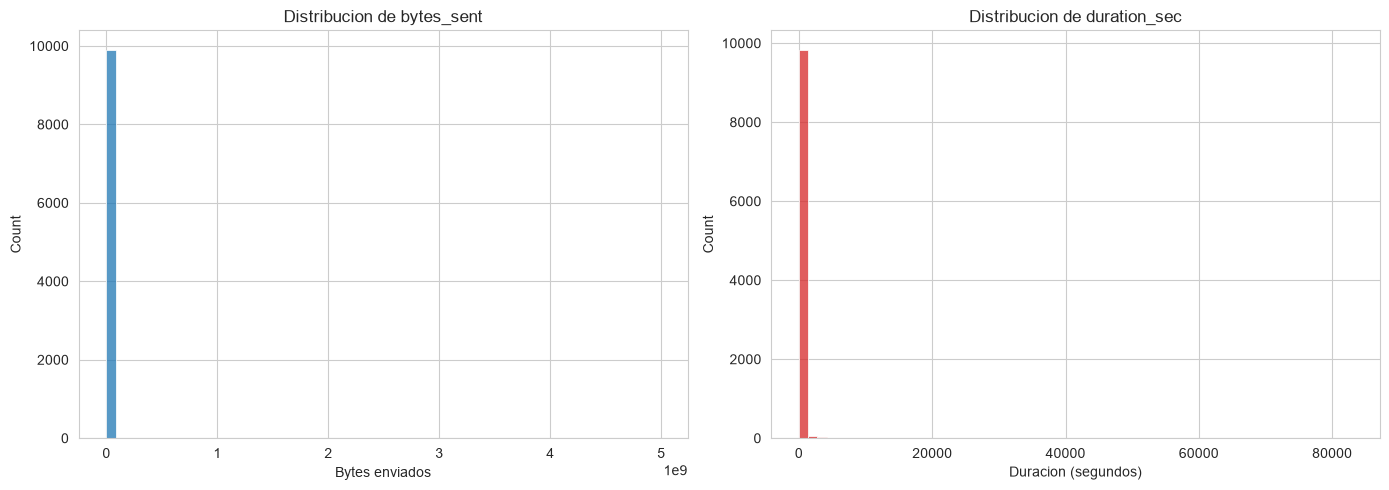

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["bytes_sent"], bins=60, ax=axes[0], color="#1f77b4")
axes[0].set_title("Distribucion de bytes_sent")
axes[0].set_xlabel("Bytes enviados")

sns.histplot(df["duration_sec"], bins=60, ax=axes[1], color="#d62728")
axes[1].set_title("Distribucion de duration_sec")
axes[1].set_xlabel("Duracion (segundos)")

plt.tight_layout()
plt.savefig("evidencias/SCR3.1_eda.png", dpi=150)
plt.show()

In [3]:
print("Valores nulos por columna:")
print(df.isnull().sum())

# Imputar nulos numericos con la mediana (robusta a outliers)
columnas_numericas = ["bytes_sent", "bytes_recv", "duration_sec", "packets"]
for col in columnas_numericas:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

# Recortar (clip) outliers extremos al percentil 99.5 para evitar que
# distorsionen el escalado, sin eliminar los registros (podrian ser anomalias reales)
for col in columnas_numericas:
    limite = df[col].quantile(0.995)
    df[col + "_clip"] = df[col].clip(upper=limite)

print("\nLimites de recorte (percentil 99.5):")
for col in columnas_numericas:
    print(f"  {col}: {df[col].quantile(0.995):,.2f}")

Valores nulos por columna:
timestamp       0
src_ip          0
dst_ip          0
dst_port        0
protocol        0
bytes_sent      0
bytes_recv      0
duration_sec    0
packets         0
label           0
dtype: int64

Limites de recorte (percentil 99.5):
  bytes_sent: 2,757,548,602.17
  bytes_recv: 9,738,384.15
  duration_sec: 40,590.79
  packets: 1,539,700.64


In [4]:
# Nueva variable 1: ratio entre bytes enviados y recibidos
# (valores muy altos = mucha salida, poca entrada -> tipico de exfiltracion)
df["ratio_bytes"] = df["bytes_sent"] / (df["bytes_recv"] + 1)

# Nueva variable 2: bytes transferidos por segundo (velocidad de transferencia)
df["bytes_por_segundo"] = (df["bytes_sent"] + df["bytes_recv"]) / (df["duration_sec"] + 0.01)

# Nueva variable 3 (extra): paquetes por segundo
df["paquetes_por_segundo"] = df["packets"] / (df["duration_sec"] + 0.01)

# Nueva variable 4 (extra): es horario no laboral (22:00-06:00)
df["hora"] = df["timestamp"].dt.hour
df["fuera_horario"] = ((df["hora"] >= 22) | (df["hora"] < 6)).astype(int)

df[["ratio_bytes", "bytes_por_segundo", "paquetes_por_segundo", "fuera_horario"]].describe()

,ratio_bytes,bytes_por_segundo,paquetes_por_segundo,fuera_horario
count,1.000000e+04,1.000000e+04,10000.000000,10000.000000
mean,4.212233e+03,1.409670e+05,110.077120,0.337000
std,1.182686e+05,1.444427e+06,1425.050806,0.472709
min,1.106611e-05,1.492779e-02,0.003934,0.000000
25%,6.337164e-02,1.980729e+03,0.274631,0.000000
50%,4.393979e-01,7.734981e+03,1.389124,0.000000
75%,3.031250e+00,3.406790e+04,7.513417,1.000000
max,9.151127e+06,7.749110e+07,75455.238095,1.000000


In [9]:
FEATURES = [
    "bytes_sent", "bytes_recv", "duration_sec", "packets",
    "ratio_bytes", "bytes_por_segundo", "paquetes_por_segundo", "fuera_horario",
]

# Log-transform en las columnas con cola muy pesada (mejora la separacion para Isolation Forest)
df_features = df[FEATURES].copy()
columnas_sesgadas = ["bytes_sent", "bytes_recv", "duration_sec", "packets",
                      "ratio_bytes", "bytes_por_segundo", "paquetes_por_segundo"]
for col in columnas_sesgadas:
    df_features[col] = np.log1p(df_features[col])

scaler = StandardScaler()
X = scaler.fit_transform(df_features)
X = pd.DataFrame(X, columns=FEATURES)
print("Features normalizadas, shape:", X.shape)
X.head()

Features normalizadas, shape: (10000, 8)


,bytes_sent,bytes_recv,duration_sec,packets,ratio_bytes,bytes_por_segundo,paquetes_por_segundo,fuera_horario
0,-0.199458,-0.027914,0.505201,-0.307893,-0.440403,-0.764067,-0.687011,1.402626
1,2.035225,0.146252,0.698325,1.868450,1.490823,0.905395,1.457097,1.402626
2,-0.033547,1.257660,-0.730133,-0.260547,-0.579859,1.237829,-0.103476,-0.712949
3,1.193207,0.064781,-1.171602,1.247721,0.567180,1.295547,2.283646,-0.712949
4,-0.198262,-0.394426,-0.124686,-0.161104,-0.283407,-0.613441,-0.368619,-0.712949


In [11]:
from sklearn.ensemble import IsolationForest

modelo = IsolationForest(
    contamination=0.05,
    n_estimators=100,
    random_state=42,
)
modelo.fit(X)

df["prediccion"] = modelo.predict(X)        # -1 = anomalia, 1 = normal
df["score_anomalia"] = modelo.decision_function(X)

print(df["prediccion"].value_counts())

prediccion
 1    9500
-1     500
Name: count, dtype: int64


In [14]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Mapear: label real "anomaly" -> -1 (igual que la convencion de Isolation Forest), "normal" -> 1
y_real = df["label"].map({"anomaly": -1, "normal": 1})
y_pred = df["prediccion"]

precision = precision_score(y_real, y_pred, pos_label=-1)
recall = recall_score(y_real, y_pred, pos_label=-1)
f1 = f1_score(y_real, y_pred, pos_label=-1)

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print()
print(classification_report(y_real, y_pred, target_names=["anomaly", "normal"], labels=[-1, 1]))

Precision: 0.8220
Recall:    0.8220
F1-Score:  0.8220

              precision    recall  f1-score   support

     anomaly       0.82      0.82      0.82       500
      normal       0.99      0.99      0.99      9500

    accuracy                           0.98     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.98      0.98      0.98     10000



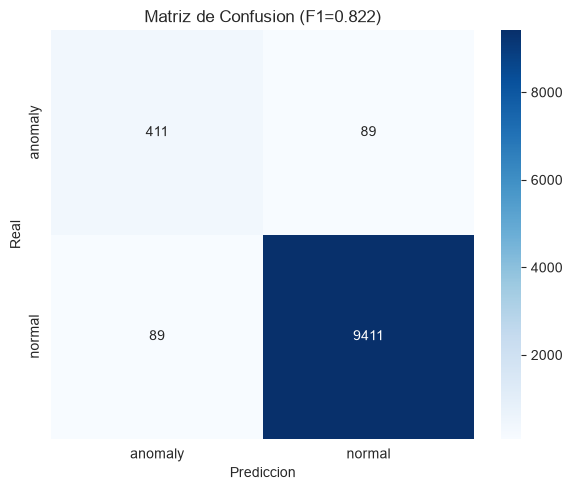

In [15]:
cm = confusion_matrix(y_real, y_pred, labels=[-1, 1])

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["anomaly", "normal"], yticklabels=["anomaly", "normal"])
plt.title(f"Matriz de Confusion (F1={f1:.3f})")
plt.xlabel("Prediccion")
plt.ylabel("Real")
plt.tight_layout()
plt.savefig("evidencias/SCR3.2_metricas.png", dpi=150)
plt.show()

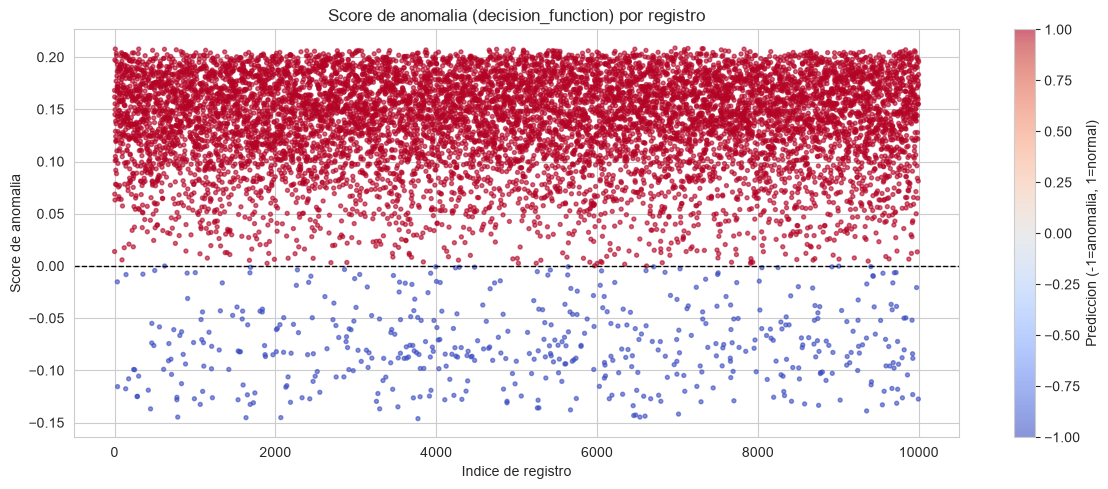

In [16]:
plt.figure(figsize=(12, 5))
plt.scatter(range(len(df)), df["score_anomalia"], c=df["prediccion"], cmap="coolwarm", s=8, alpha=0.6)
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("Score de anomalia (decision_function) por registro")
plt.xlabel("Indice de registro")
plt.ylabel("Score de anomalia")
plt.colorbar(label="Prediccion (-1=anomalia, 1=normal)")
plt.tight_layout()
plt.show()

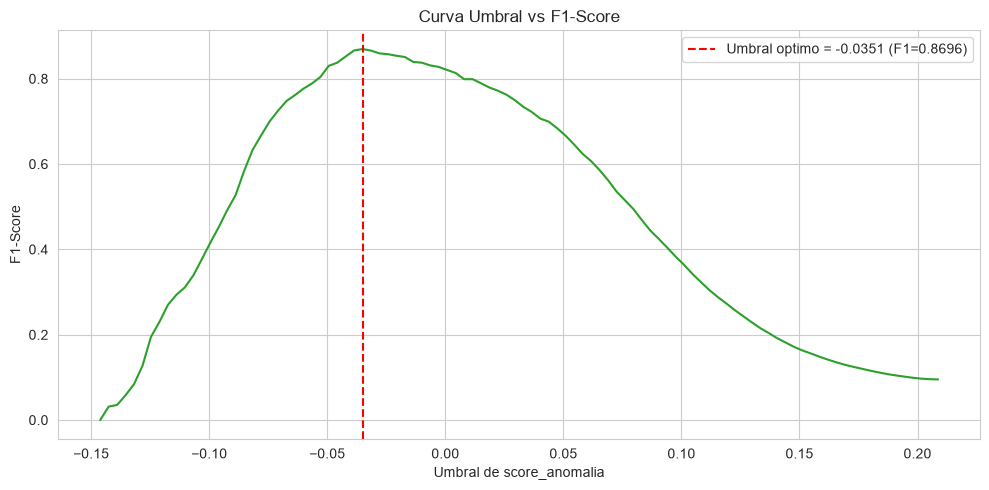

Umbral optimo encontrado: -0.0351  ->  F1-Score: 0.8696


In [17]:
from sklearn.metrics import f1_score as f1_fn

umbrales = np.linspace(df["score_anomalia"].min(), df["score_anomalia"].max(), 100)
f1_scores = []

for u in umbrales:
    pred_u = np.where(df["score_anomalia"] < u, -1, 1)
    f1_scores.append(f1_fn(y_real, pred_u, pos_label=-1))

mejor_idx = int(np.argmax(f1_scores))
mejor_umbral = umbrales[mejor_idx]
mejor_f1 = f1_scores[mejor_idx]

plt.figure(figsize=(10, 5))
plt.plot(umbrales, f1_scores, color="#2ca02c")
plt.axvline(mejor_umbral, color="red", linestyle="--",
            label=f"Umbral optimo = {mejor_umbral:.4f} (F1={mejor_f1:.4f})")
plt.title("Curva Umbral vs F1-Score")
plt.xlabel("Umbral de score_anomalia")
plt.ylabel("F1-Score")
plt.legend()
plt.tight_layout()
plt.savefig("evidencias/SCR3.3_umbral_f1.png", dpi=150)
plt.show()

print(f"Umbral optimo encontrado: {mejor_umbral:.4f}  ->  F1-Score: {mejor_f1:.4f}")

In [18]:
top10_anomalos = df.sort_values("score_anomalia").head(10)
top10_anomalos[["timestamp", "src_ip", "dst_ip", "dst_port", "protocol",
                "bytes_sent", "bytes_recv", "duration_sec", "packets",
                "score_anomalia", "label"]]

,timestamp,src_ip,dst_ip,dst_port,protocol,bytes_sent,bytes_recv,duration_sec,packets,score_anomalia,label
3773,2024-05-07 05:39:15,10.0.1.114,185.220.101.45,8080,TCP,4602183026,43276,682.60,2052006,-0.146186,anomaly
1635,2024-05-21 05:30:36,10.0.3.87,31.228.172.177,80,TCP,3247805983,10420,753.14,1542813,-0.145283,anomaly
2068,2024-05-03 00:20:22,10.0.1.180,162.142.107.84,8080,TCP,4155915523,28819,1037.92,1987107,-0.145198,anomaly
6533,2024-05-02 03:29:37,10.0.0.237,23.129.64.214,443,TCP,4126191812,41212,767.75,1626052,-0.144704,anomaly
786,2024-05-09 00:59:47,10.0.1.114,178.249.13.75,53,TCP,3385524170,18133,451.40,2532734,-0.144704,anomaly
6597,2024-05-04 04:44:10,10.0.0.93,185.220.101.45,8080,TCP,2739832080,11140,342.89,1882321,-0.143803,anomaly
6456,2024-05-17 04:39:05,10.0.1.254,38.168.189.92,80,UDP,4696305972,21229,383.65,1693674,-0.143226,anomaly
6480,2024-05-24 05:37:17,10.0.0.237,179.227.63.96,53,UDP,4112441880,36145,1020.62,1612806,-0.142733,anomaly
7013,2024-05-17 05:49:48,10.0.1.180,185.220.101.45,8080,TCP,2648843692,10798,817.83,2205266,-0.141834,anomaly
9352,2024-05-23 02:21:39,10.0.3.174,185.220.101.45,443,TCP,4987050489,17471,1826.01,2237917,-0.138808,anomaly


Los registros del Top 10 presentan volumenes de bytes_sent extremadamente altos (2.6 a 5 mil 
millones de bytes) frente a bytes_recv mucho menores, generando un ratio_bytes muy desbalanceado 
tipico de exfiltracion de datos. Varios casos comparten el puerto 8080 y la IP de destino 
185.220.101.45, lo cual sugiere un mismo servidor de destino recurrente, un patron consistente con 
un canal de exfiltracion reutilizado. La combinacion de gran volumen de salida, baja proporcion de 
datos recibidos y destinos repetidos justifica que el modelo los priorice como anomalias de alto 
riesgo, coherente con la logica de la regla de exfiltracion definida en el Laboratorio 2.

In [19]:
import joblib

joblib.dump(modelo, "modelo_anomalias.pkl")
joblib.dump(scaler, "scaler.pkl")
print("[OK] Modelo y scaler exportados.")

[OK] Modelo y scaler exportados.
